In [27]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math


### Question 1

##### Load Dataset

In [28]:
D = np.genfromtxt('assets/lines.csv', delimiter=',', skip_header=1)

print('Dataset shape:', D.shape)
X_cols = D[:, :3]
Y_cols = D[:, 3:]

x_all = X_cols.flatten()
y_all = Y_cols.flatten()

Dataset shape: (100, 6)


#### Q1(a)

In [29]:

x1 = D[:, 0]
y1 = D[:, 3]

X_ = np.column_stack((x1, y1))
U = X_ - np.mean(X_, axis=0)

_, _, Vt = np.linalg.svd(np.transpose(U) @ U)
a, b = Vt[-1, 0], Vt[-1, 1]

d = a * np.mean(x1) + b * np.mean(y1)

best_model_line = np.array([a, b, d])
print("TLS Resulting Parameters [a, b, d]:", best_model_line)

TLS Resulting Parameters [a, b, d]: [-0.77356165  0.63372105 -3.79419221]


#### Q1(b)

Line 1 parameters: m = -0.4672, c = 2.0878
Line 2 parameters: m = 1.0321, c = 1.1369
Line 3 parameters: m = 1.1664, c = -6.0941


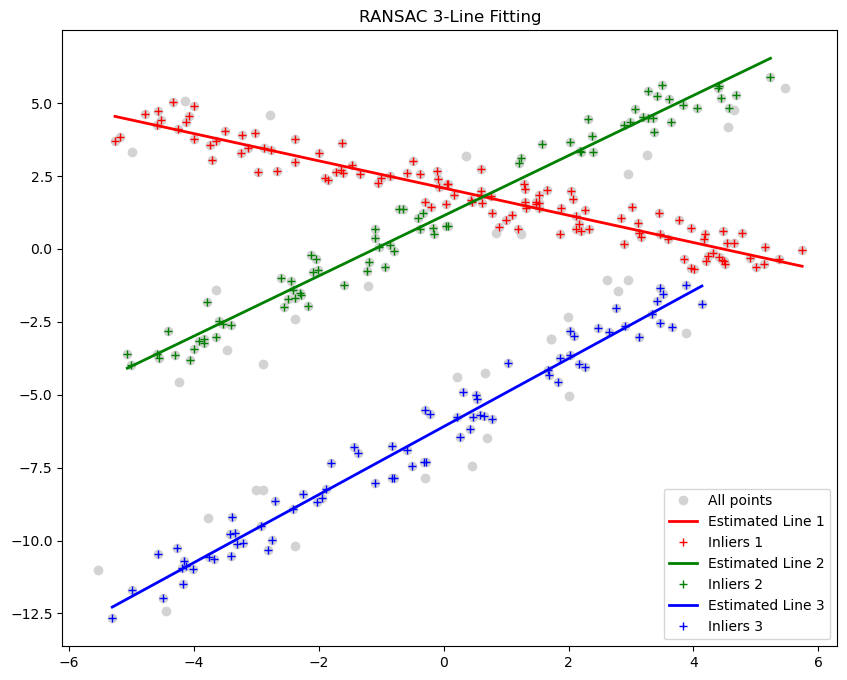

In [32]:
def line(x, y):
    m = (y[1] - y[0]) / (x[1] - x[0])
    b = y[0] - m * x[0]
    # y = mx + b => mx - y + b = 0
    # To match a*x + b*y - d = 0, we set d = -b
    return m, -1, -b 

def distance(parameters, x, y):
    a = parameters[0]
    b = parameters[1]
    d = parameters[2]
    return (a*x + b*y - d)**2

thresh = 1.0 # Distance threshold for inliers
s = 2
max_iterations = 100

plt.figure(figsize=(10, 8))
plt.plot(x, y, 'o', label='All points', color='lightgray')

colors = ['r', 'g', 'b']

# 3. Find 3 lines iteratively
for i in range(3):
    best_consensus = []
    max_inliers = 0
    
    # RANSAC Loop: Find the model with the most inliers
    for _ in range(max_iterations):
        samples = np.random.choice(len(x), s, replace=False)
        xs = x[samples]
        ys = y[samples]
        
        # Avoid division by zero
        if xs[1] - xs[0] == 0:
            continue
            
        parameters = line(xs, ys)
        dist = distance(parameters, x, y)
        consensus = dist < thresh
        num_inliers = sum(consensus)
        
        if num_inliers > max_inliers:
            max_inliers = num_inliers
            best_consensus = consensus
            
    # Extract the consensus set (inliers) for the best line
    xc = x[best_consensus]
    yc = y[best_consensus]
    
    # Refit the line using ALL inliers via Pseudo-Inverse Least Squares
    X = np.concatenate([xc.reshape(len(xc),1), np.ones((len(xc), 1))], axis=1)
    B = np.linalg.pinv(X.T @ X) @ X.T @ yc
    mstar = B[0]
    cstar = B[1]
    
    print(f"Line {i+1} parameters: m = {mstar:.4f}, c = {cstar:.4f}")
    
    # Plot the inliers and the estimated line
    x_line = np.array([xc.min(), xc.max()])
    plt.plot(x_line, mstar * x_line + cstar, color=colors[i], linestyle='-', linewidth=2, label=f'Estimated Line {i+1}')
    plt.plot(xc, yc, '+', color=colors[i], label=f'Inliers {i+1}')
    
    # Mask out the consensus set so they are not used to find the next line
    x = x[~best_consensus]
    y = y[~best_consensus]

plt.legend(loc='best')
plt.title("RANSAC 3-Line Fitting")
plt.show()

#### Q2

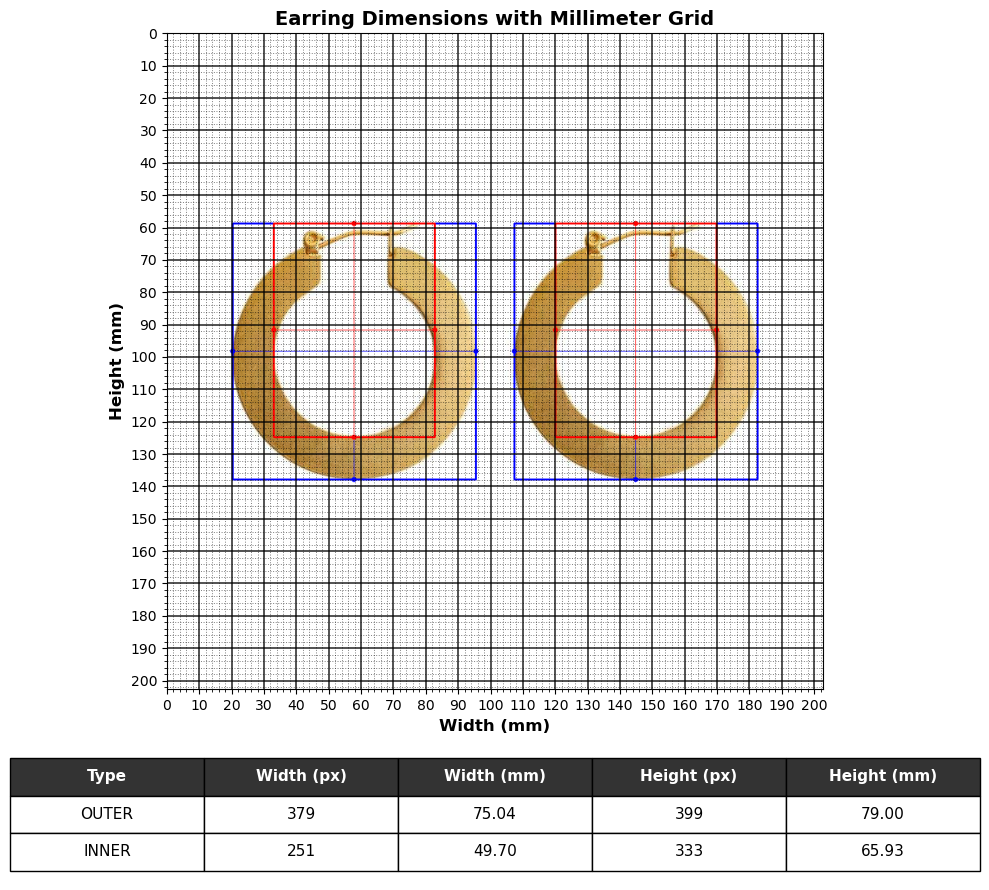

In [ ]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

f_mm = 8.0
Z_mm = 720.0
pixel_pitch_mm = 0.0022
# Note: This approximation (Z / f) treats Z_mm as the object distance.
mm_per_pixel = (pixel_pitch_mm * Z_mm) / f_mm

# Load Image
img = cv2.imread("assets/earrings.jpg")
img_annotated = img.copy()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Threshold to isolate the shapes
_, thresh = cv2.threshold(gray, 220, 255, cv2.THRESH_BINARY_INV)

# Draw Bounding Boxes using RETR_TREE to get parent/child relationships
contours, hierarchy = cv2.findContours(
    thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

boxes = {}
for i, contour in enumerate(contours):
    boxes[i] = cv2.boundingRect(contour)

table_data = []
measured_outer = False
measured_inner = False

for i, contour in enumerate(contours):
    if cv2.contourArea(contour) > 500:
        
        parent_idx = hierarchy[0][i][3]
        is_outer = (parent_idx == -1)
        label = "OUTER Box" if is_outer else "INNER Box"
        table_label = "OUTER" if is_outer else "INNER"

        # Blue for Outer, Red for Inner
        box_color = (255, 0, 0) if is_outer else (0, 0, 255)

        bx, by, bw, bh = boxes[i]

        # Adjust inner box top point to match outer box top point
        if not is_outer and parent_idx in boxes:
            p_bx, p_by, p_bw, p_bh = boxes[parent_idx]
            original_bottom = by + bh

            by = p_by  # Make the inner top point the exact same as the outer top point
            bh = original_bottom - by  # Recalculate the height based on the new top

        # Record Outer Dimensions
        if is_outer and not measured_outer:
            real_w_mm = bw * mm_per_pixel
            real_h_mm = bh * mm_per_pixel
            table_data.append(
                [table_label, f"{bw}", f"{real_w_mm:.2f}", f"{bh}", f"{real_h_mm:.2f}"])
            measured_outer = True

        # Record Inner Dimensions
        elif not is_outer and not measured_inner:
            real_w_mm = bw * mm_per_pixel
            real_h_mm = bh * mm_per_pixel
            table_data.append(
                [table_label, f"{bw}", f"{real_w_mm:.2f}", f"{bh}", f"{real_h_mm:.2f}"])
            measured_inner = True

        # Draw Rectangle and Crosshairs
        cv2.rectangle(img_annotated, (bx, by),
                      (bx + bw, by + bh), box_color, 2)

        y_center = by + (bh // 2)
        cv2.line(img_annotated, (bx, y_center),
                 (bx + bw, y_center), box_color, 1)
        cv2.circle(img_annotated, (bx, y_center), 4, box_color, -1)
        cv2.circle(img_annotated, (bx + bw, y_center), 4, box_color, -1)

        x_center = bx + (bw // 2)
        cv2.line(img_annotated, (x_center, by),
                 (x_center, by + bh), box_color, 1)
        cv2.circle(img_annotated, (x_center, by), 4, box_color, -1)
        cv2.circle(img_annotated, (x_center, by + bh), 4, box_color, -1)

img_annotated_rgb = cv2.cvtColor(img_annotated, cv2.COLOR_BGR2RGB)

height_px, width_px, _ = img_rgb.shape
total_width_mm = width_px * mm_per_pixel
total_height_mm = height_px * mm_per_pixel

fig, (ax_img, ax_table) = plt.subplots(nrows=2, ncols=1, figsize=(10, 9), gridspec_kw={'height_ratios': [5, 1]})

# Map image extent to actual millimeters
ax_img.imshow(img_annotated_rgb, extent=[0, total_width_mm, total_height_mm, 0])

# Configure Axis Ticks for mm Grid
ax_img.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax_img.yaxis.set_major_locator(ticker.MultipleLocator(10))
ax_img.xaxis.set_minor_locator(ticker.MultipleLocator(2))
ax_img.yaxis.set_minor_locator(ticker.MultipleLocator(2))

ax_img.grid(which='major', color='black',
            linestyle='-', linewidth=1.2, alpha=0.8)
ax_img.grid(which='minor', color='black',
            linestyle=':', linewidth=0.7, alpha=0.5)

ax_img.set_xlabel("Width (mm)", fontsize=12, fontweight='bold')
ax_img.set_ylabel("Height (mm)", fontsize=12, fontweight='bold')
ax_img.set_title("Earring Dimensions with Millimeter Grid",
                 fontsize=14, fontweight='bold')

ax_table.axis('off')
col_labels = ["Type", "Width (px)", "Width (mm)", "Height (px)", "Height (mm)"]
table = ax_table.table(cellText=table_data,
                       colLabels=col_labels, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('black')
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#333333')
    else:
        cell.set_facecolor('#ffffff')

# Save and Show
plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/earrings_bounding_boxes.png", dpi=300)
plt.show()